In [232]:
%matplotlib ipympl

In [233]:
import numpy as np
import scipy.constants as const

import scqubits as scq
hbar = const.hbar


# 1. Define physical constants and conversion factors
h = const.h                      # Planck constant in J*s
e = const.e                      # Elementary charge in C
Phi0 = h / (2 * e)               # Magnetic flux quantum in Wb
GHz = 1e9                        # Conversion for Hz to GHz
fF_to_F = 1e-15                  # femtoFarad to Farad

# 2. Define input parameters
fp_target_GHz = 30          # Target plasma frequency in GHz
wp_target = 2 * np.pi * fp_target_GHz * GHz # Target angular frequency in rad/s

# Junction dimensions
W_um = 0.260                       # Width in um (260 nm)
L_um = 2.4                       # Length in um
N = 100                 # number of cells
# for N in [120]:

C_area_fF_per_um2 = 45.0         # Capacitance per unit area in fF/um^2 (Assumed)

# 3. Calculate Junction Capacitance (C_J)
Area_um2 = W_um * L_um
CJ = C_area_fF_per_um2 * Area_um2 * fF_to_F # Junction capacitance C in Farads (F)

# 4. Calculate Josephson Inductance (L_J)
# Formula: wp = 1/sqrt(LJ * CJ) => LJ = 1 / (wp^2 * CJ)
LJ = 1.0 / (wp_target**2 * CJ)  # Josephson Inductance L in Henries (H)

# 5. Calculate Josephson Energy (E_J)
# Formula: EJ = (Phi0 / (2*pi))^2 / LJ
EJ = (Phi0 / (2 * np.pi))**2 / LJ # Josephson Energy EJ in Joules (J)
EJ_GHz = EJ / h  / GHz              # Josephson Energy EJ in GHz

# 6. Calculate Charging Energy (E_C)
# Formula: EC = e^2 / (2 * (2 * CJ))
EC = e**2 / (2 * CJ)             # Charging Energy EC in Joules (J)
EC_GHz = EC / h  / GHz                  # Charging Energy EC in GHz


# Cg_over_CJ = 0.10       # stray-to-ground ratio
Cg = 20e-18 ###Cg_over_CJ * CJ

# --- Chain design targets (edit here) ---
a = W_um * 1e-6                # cell pitch [m] (for bookkeeping; not critical here)


#########################################
R = 50.0                       # target wave impedance [Ohm]
########################################


# Qubit junction dimensions
W_um = 0.260                       # Width in um (260 nm)
L_um = 2.0                         # Length in um

Area_um2 = W_um * L_um
CJ_qubit = C_area_fF_per_um2 * Area_um2 * fF_to_F # Junction capacitance C in Farads (F)
CJ_qubit = CJ_qubit # for one junction;

LJ_qubit = 1.0 / (wp_target**2 * CJ_qubit)  # Josephson Inductance L in Henries (H)

EJ_qubit = 2*(Phi0 / (2 * np.pi))**2 / LJ_qubit # Josephson Energy EJ in Joules (J) # factor of 2 for the SQUID
EJ_qubit_GHz = EJ_qubit / h  / GHz              # Josephson Energy EJ in GHz

EC_qubit = e**2 / (2 * CJ_qubit * 2)             # Charging Energy EC in Joules (J) # factor of 2 for the SQUID since the two junctions are in parallel, so total C is 2*CJ_qubit
EC_qubit_GHz = EC_qubit / h  / GHz                  # Charging Energy EC in GHz


d = 0.05

Phi_ext = 0.5*Phi0


Cc = 1e-15             # [F]

N_SQUID = N // 2


qubit_params = {
    'EJ_GHz': EJ_qubit_GHz,
    'EC_GHz': EC_qubit_GHz,
    'd': d,
    'ng': 0.0,
    'ncut': 20,
    'truncated_dim': 10,
    'CJ': CJ_qubit*2, # total capacitance of the SQUID (two junctions in parallel)
}

In [234]:
print("Junction parameters:")
print(f"  C_J = {CJ*1e15:.2f} fF")
print(f"  L_J = {LJ*1e9:.2f} nH")
print(f"  E_J = {EJ_GHz:.2f} GHz")
print(f"  E_C = {EC_GHz:.2f} GHz")
print(f"  E_J/E_C = {EJ_GHz/EC_GHz:.2f}")
print(f"  C_g = {Cg*1e18:.2f} aF")
print()
print("Qubit parameters:")
print(f"  C_J = {CJ_qubit*1e15:.2f} fF")
print(f"  L_J = {LJ_qubit*1e9:.2f} nH")
print(f"  E_J = {EJ_qubit_GHz:.2f} GHz")
print(f"  E_C = {EC_qubit_GHz:.2f} GHz")
print(f"  E_J/E_C = {EJ_qubit_GHz/EC_qubit_GHz:.2f}")

Junction parameters:
  C_J = 28.08 fF
  L_J = 1.00 nH
  E_J = 163.09 GHz
  E_C = 0.69 GHz
  E_J/E_C = 236.42
  C_g = 20.00 aF

Qubit parameters:
  C_J = 23.40 fF
  L_J = 1.20 nH
  E_J = 271.81 GHz
  E_C = 0.41 GHz
  E_J/E_C = 656.71


In [235]:
print("SQUID EJ at half-flux with an:")
print(f"  asymmetry d = {d:.2f}")
print(f"  E_J_SQUID = {EJ_qubit_GHz * np.cos(np.pi * Phi_ext / Phi0) * np.sqrt(1 + d**2 * np.tan(np.pi * Phi_ext / Phi0)**2):.2f} GHz")
print(f"EJ/EC at half-flux with an asymmetry d = {d:.2f}:",
      EJ_qubit_GHz * np.cos(np.pi * Phi_ext / Phi0) * np.sqrt(1 + d**2 * np.tan(np.pi * Phi_ext / Phi0)**2) / EC_qubit_GHz) 

print(f"Freq at half-flux with an asymmetry d = {d:.2f}:",
      np.sqrt(8 * EJ_qubit_GHz * np.cos(np.pi * Phi_ext / Phi0) * np.sqrt(1 + d**2 * np.tan(np.pi * Phi_ext / Phi0)**2) * EC_qubit_GHz) - EC_qubit_GHz)

SQUID EJ at half-flux with an:
  asymmetry d = 0.05
  E_J_SQUID = 13.59 GHz
EJ/EC at half-flux with an asymmetry d = 0.05: 32.835581226137506
Freq at half-flux with an asymmetry d = 0.05: 6.294310143510926


In [236]:
import numpy as np
import pandas as pd

def extract_Cg_Cc_from_q3d_csv_debug(
    path,
    gnd_name="gnd",
    strip_name="strip",
    lower_prefix="lower_chain",
    upper_prefixes=("upped_chain", "upper_chain"),
    debug=True,
    debug_max_names=10,
):
    # --------------------------------------------------
    # 0) Read file and find header line
    # --------------------------------------------------
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    header_idx = None
    for i, ln in enumerate(lines):
        # Q3D matrices usually have a header row like: ,gnd,strip,lower_chain,...
        if ln.startswith(",") and (gnd_name in ln):
            header_idx = i
            break

    if header_idx is None:
        raise RuntimeError("Could not detect capacitance matrix header line (starts with ',' and contains gnd).")

    if debug:
        print(f"[DEBUG] header_idx = {header_idx}")
        print(f"[DEBUG] header line preview:\n{lines[header_idx].strip()[:200]}...")

    # --------------------------------------------------
    # 1) Load into DataFrame
    # --------------------------------------------------
    df = pd.read_csv(path, skiprows=header_idx, header=0)
    if debug:
        print(f"[DEBUG] raw df shape = {df.shape}")
        print(f"[DEBUG] raw df columns (first 12) = {list(df.columns[:12])}")

    # Rename first column to "name"
    df = df.rename(columns={df.columns[0]: "name"})

    # Drop rows where name is NaN
    before = len(df)
    df = df.dropna(subset=["name"])
    if debug:
        print(f"[DEBUG] dropped {before - len(df)} rows with NaN name; remaining rows = {len(df)}")

    # Force name to string
    df["name"] = df["name"].astype(str).map(lambda s: s.strip())
    df = df.set_index("name")

    # Drop columns that are fully NaN
    before_cols = df.shape[1]
    df = df.dropna(axis=1, how="all")
    if debug:
        print(f"[DEBUG] dropped {before_cols - df.shape[1]} all-NaN columns; now cols = {df.shape[1]}")

    # Clean column labels
    df.columns = [str(c).strip() for c in df.columns]
    df.index = [str(i).strip() for i in df.index]

    if debug:
        print(f"[DEBUG] cleaned df shape = {df.shape}")
        print(f"[DEBUG] index sample (first {min(debug_max_names, len(df.index))}) = {list(df.index[:min(debug_max_names, len(df.index))])}")
        print(f"[DEBUG] col sample   (first {min(debug_max_names, len(df.columns))}) = {list(df.columns[:min(debug_max_names, len(df.columns))])}")

    # --------------------------------------------------
    # 2) IMPORTANT: ensure unique labels
    #     Your error "float(series)" strongly suggests duplicate columns
    #     such that df.loc[row, col] returns a Series, not a scalar.
    # --------------------------------------------------
    dup_cols = df.columns[df.columns.duplicated()].tolist()
    dup_rows = df.index[df.index.duplicated()].tolist()
    if debug:
        print(f"[DEBUG] duplicated columns count = {len(dup_cols)}")
        print(f"[DEBUG] duplicated rows count    = {len(dup_rows)}")
        if len(dup_cols) > 0:
            print(f"[DEBUG] example duplicated columns: {dup_cols[:10]}")
        if len(dup_rows) > 0:
            print(f"[DEBUG] example duplicated rows: {dup_rows[:10]}")

    # If duplicates exist, we must resolve them deterministically.
    # Strategy:
    #  - For duplicated columns: keep the first occurrence.
    #  - For duplicated rows: keep the first occurrence.
    if len(dup_cols) > 0:
        if debug:
            print("[DEBUG] resolving duplicate columns by keeping first occurrence")
        df = df.loc[:, ~df.columns.duplicated(keep="first")]

    if len(dup_rows) > 0:
        if debug:
            print("[DEBUG] resolving duplicate rows by keeping first occurrence")
        df = df[~df.index.duplicated(keep="first")]

    if debug:
        print(f"[DEBUG] df shape after dedup = {df.shape}")

    # --------------------------------------------------
    # 3) Convert all numeric entries safely
    # --------------------------------------------------
    # Some Q3D exports include stray non-numeric tokens; coerce -> NaN, then we can detect them.
    df_num = df.apply(pd.to_numeric, errors="coerce")
    if debug:
        nan_count = int(np.isnan(df_num.to_numpy()).sum())
        total = df_num.size
        print(f"[DEBUG] numeric coercion done. NaNs in numeric matrix: {nan_count}/{total}")

    # Replace df with numeric version for access
    df = df_num

    # --------------------------------------------------
    # 4) Mutual capacitance accessor
    # --------------------------------------------------
    def C_mut(a, b):
        if a not in df.index:
            raise KeyError(f"[C_mut] Row '{a}' not found.")
        if b not in df.columns:
            raise KeyError(f"[C_mut] Column '{b}' not found.")

        val = df.loc[a, b]

        # Debug: ensure scalar
        if isinstance(val, pd.Series):
            # This means column label still not unique, or multiindex scenario.
            raise RuntimeError(
                f"[C_mut] df.loc[{a!r}, {b!r}] returned a Series (len={len(val)}). "
                f"This indicates duplicate columns still exist. "
                f"Series head:\n{val.head()}"
            )

        if pd.isna(val):
            raise RuntimeError(f"[C_mut] Value at ({a}, {b}) is NaN (non-numeric or missing).")

        return -float(val)  # fF (mutual = -Maxwell off-diagonal)

    # --------------------------------------------------
    # 5) Identify conductor names for rails
    # --------------------------------------------------
    lower_names = [n for n in df.index if (n == lower_prefix or n.startswith(lower_prefix + "_"))]

    def is_upper(n):
        return any(n == p or n.startswith(p + "_") for p in upper_prefixes)

    upper_names = [n for n in df.index if is_upper(n)]

    def sort_key(name, prefix):
        if name == prefix:
            return 0
        try:
            return int(name.split(prefix + "_", 1)[1])
        except:
            return 10**9

    lower_names = sorted(lower_names, key=lambda n: sort_key(n, lower_prefix))

    upper_prefix = None
    for p in upper_prefixes:
        if any(n == p or n.startswith(p + "_") for n in upper_names):
            upper_prefix = p
            break
    if upper_prefix is None:
        raise RuntimeError(f"Upper rail prefix not found among {upper_prefixes}.")

    upper_names = sorted(upper_names, key=lambda n: sort_key(n, upper_prefix))

    if debug:
        print(f"[DEBUG] found lower_names = {len(lower_names)}, upper_names = {len(upper_names)}")
        print(f"[DEBUG] lower head: {lower_names[:5]}")
        print(f"[DEBUG] upper head: {upper_names[:5]}")
        print(f"[DEBUG] lower tail: {lower_names[-5:]}")
        print(f"[DEBUG] upper tail: {upper_names[-5:]}")

    M = min(len(lower_names), len(upper_names))
    if M == 0:
        raise RuntimeError("No rail conductors found. Check prefixes.")
    N_islands = 2 * M

    # Sanity checks for special nodes
    if strip_name not in df.index:
        # Sometimes strip may appear as a column but not a row, depending on export.
        # We'll check both and report.
        if debug:
            print(f"[DEBUG] '{strip_name}' not found in rows. Is it in columns? {strip_name in df.columns}")
        raise RuntimeError(f"'{strip_name}' conductor not found as a ROW in the matrix.")
    if gnd_name not in df.columns:
        if debug:
            print(f"[DEBUG] '{gnd_name}' not found in columns. Is it in rows? {gnd_name in df.index}")
        raise RuntimeError(f"'{gnd_name}' conductor not found as a COLUMN in the matrix.")

    if debug:
        print(f"[DEBUG] using M={M} unit cells => N_islands={N_islands} interleaved nodes")

    # --------------------------------------------------
    # 6) Build interleaved arrays
    # --------------------------------------------------
    Cg = np.zeros(N_islands, dtype=float)
    Cc = np.zeros(N_islands, dtype=float)

    for j in range(1, N_islands + 1):
        if j % 2 == 1:
            conductor = lower_names[(j - 1) // 2]
        else:
            conductor = upper_names[(j - 2) // 2]

        if debug and j <= 6:
            print(f"[DEBUG] node j={j}: conductor='{conductor}'")

        # Cg: island to gnd
        Cg[j - 1] = C_mut(conductor, gnd_name)

        # Cc: strip to island
        Cc[j - 1] = C_mut(strip_name, conductor)

        if debug and j <= 6:
            print(f"        Cg[{j-1}]={Cg[j-1]:.6g} fF,  Cc[{j-1}]={Cc[j-1]:.6g} fF")

    info = dict(
        header_idx=header_idx,
        df_shape=df.shape,
        M=M,
        N_islands=N_islands,
        lower_prefix=lower_prefix,
        upper_prefix=upper_prefix,
        strip_name=strip_name,
        gnd_name=gnd_name,
    )
    return Cg, Cc, info


# -------------------------
# Example usage
# -------------------------
path = r"C:\Users\gusarov\Desktop\3D_chain_capacitance_calc_Q3DDesign1_spacingCoupling0.25um.csv"
Cg_fF, Cc_fF, info = extract_Cg_Cc_from_q3d_csv_debug(path, debug=True)

Cg_array = np.array(Cg_fF) * fF_to_F
Cc_array = np.array(Cc_fF) * fF_to_F

print("\n[RESULT] info:", info)
print("[RESULT] Cg first 10:", Cg_array[:10])
print("[RESULT] Cc first 10:", Cc_array[:10])

Cg_array = Cg#Cg_array[:10] # Cg
Cc_array = Cc#Cc_array[:10] # Cc

[DEBUG] header_idx = 8
[DEBUG] header line preview:
,gnd,lower_chain,lower_chain_1,lower_chain_2,lower_chain_3,lower_chain_4,lower_chain_5,lower_chain_6,lower_chain_7,lower_chain_8,lower_chain_9,lower_chain_10,lower_chain_11,lower_chain_12,lower_chain_...
[DEBUG] raw df shape = (207, 103)
[DEBUG] raw df columns (first 12) = ['Unnamed: 0', 'gnd', 'lower_chain', 'lower_chain_1', 'lower_chain_2', 'lower_chain_3', 'lower_chain_4', 'lower_chain_5', 'lower_chain_6', 'lower_chain_7', 'lower_chain_8', 'lower_chain_9']
[DEBUG] dropped 2 rows with NaN name; remaining rows = 205
[DEBUG] dropped 0 all-NaN columns; now cols = 102
[DEBUG] cleaned df shape = (205, 102)
[DEBUG] index sample (first 10) = ['gnd', 'lower_chain', 'lower_chain_1', 'lower_chain_2', 'lower_chain_3', 'lower_chain_4', 'lower_chain_5', 'lower_chain_6', 'lower_chain_7', 'lower_chain_8']
[DEBUG] col sample   (first 10) = ['gnd', 'lower_chain', 'lower_chain_1', 'lower_chain_2', 'lower_chain_3', 'lower_chain_4', 'lower_chain_5', 'l

Computing matrix-chain modes (plain)...
Computing matrix-chain modes (with SQUID)...


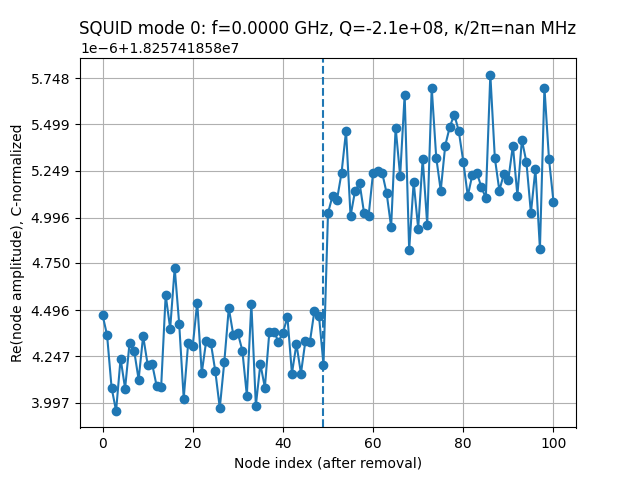

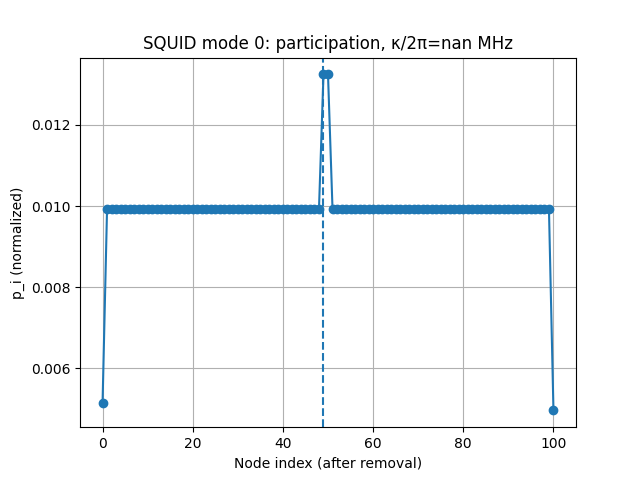

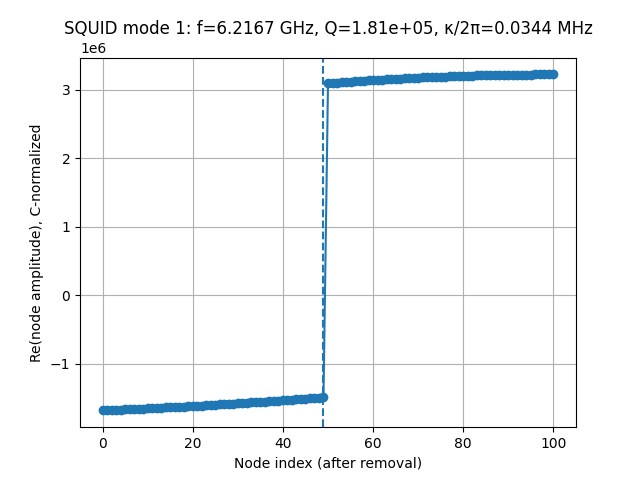

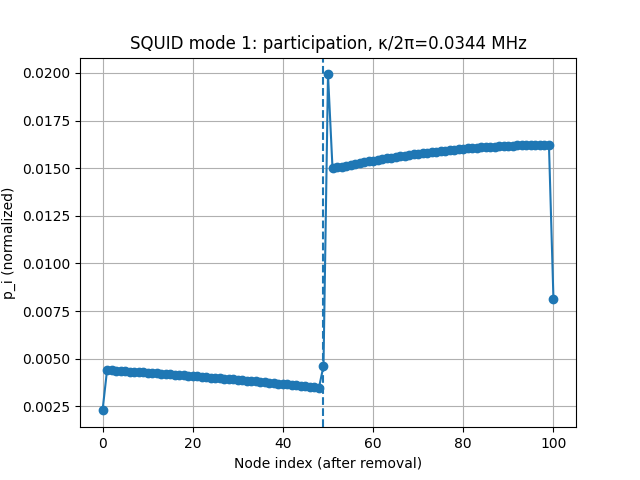

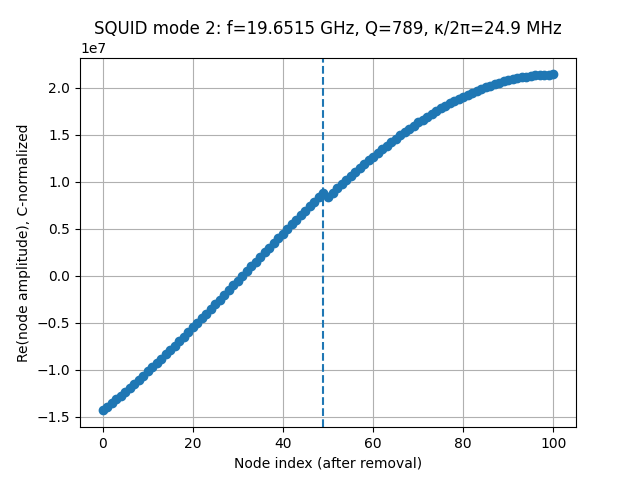

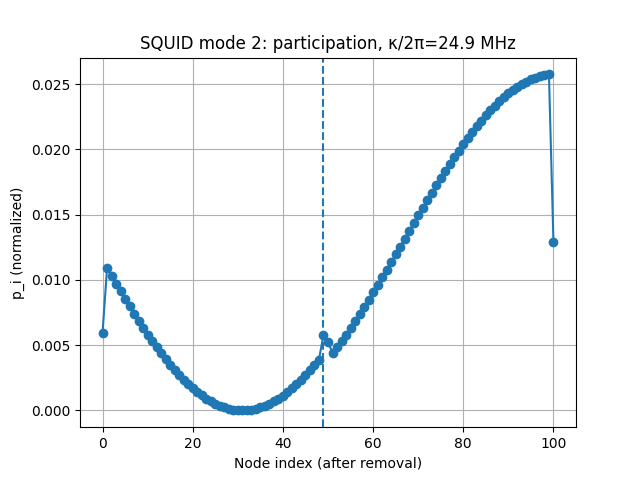

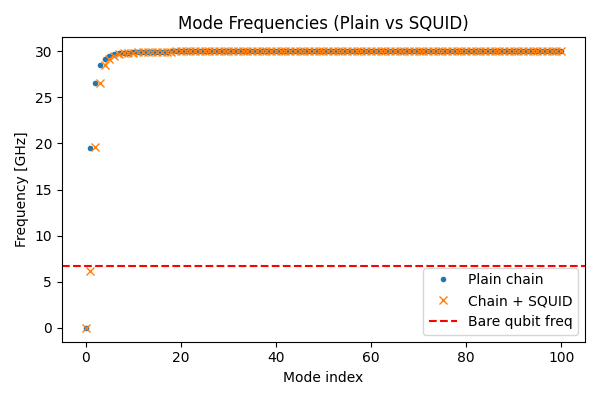

Computing Y_env(f)...


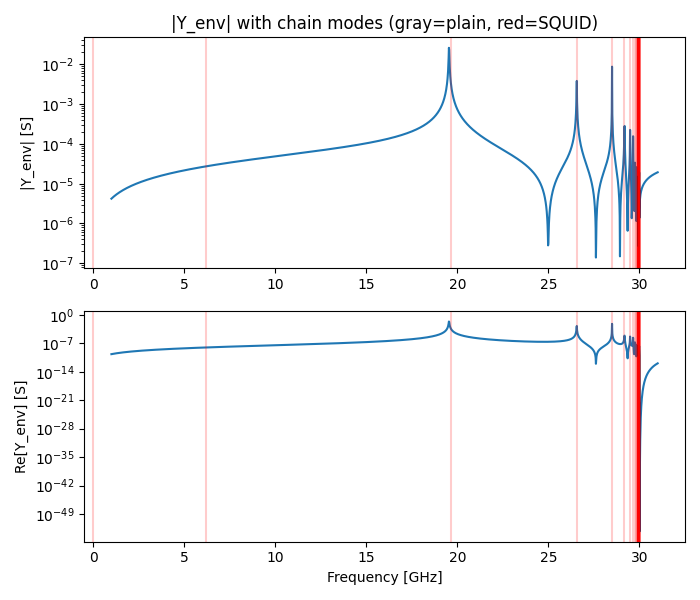

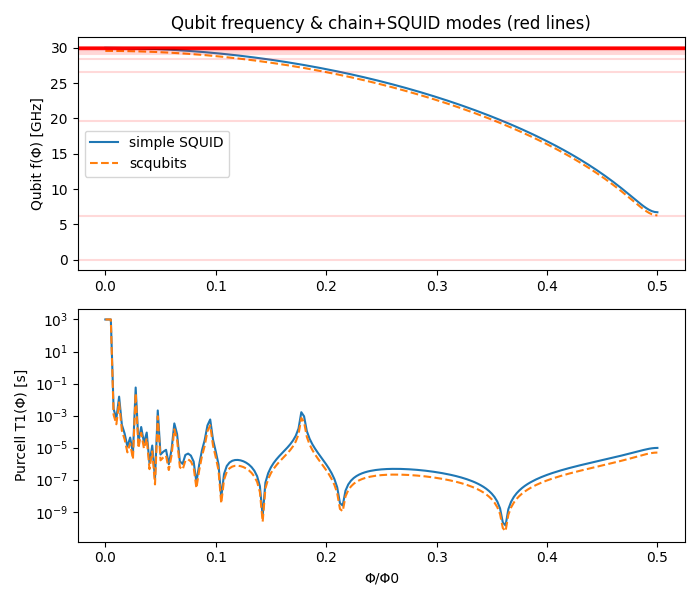

Purcell T1 4.9229305368802304e-06 s at Φ = 0.5 Φ0


In [237]:
import numpy as np
import scipy.constants as const
import matplotlib.pyplot as plt
from numpy.linalg import inv, eig

# ======================================================================
# 0. CONSTANTS
# ======================================================================

h = const.h
e = const.e
pi = np.pi
Phi0 = h / (2 * e)   # flux quantum [Wb]


# ======================================================================
# 1. SQUID + TRANSMON BASICS  (USED FOR PURCELL, NOT FOR MATRIX MODES)
# ======================================================================

def squid_EJ_eff(EJ, d, Phi_ext):
    EJ1 = EJ * (1 + d)
    EJ2 = EJ * (1 - d)
    return np.sqrt(EJ1**2 + EJ2**2 + 2 * EJ1 * EJ2 * np.cos(2*pi*Phi_ext/Phi0))

def squid_LJ(EJ_eff):
    return Phi0**2 / (4 * pi**2 * EJ_eff)

def squid_plasma_freq(EJ_eff, Cq):
    Lj = squid_LJ(EJ_eff)
    return 1.0 / np.sqrt(Lj * Cq)       # [rad/s]


# ======================================================================
# 2. ENVIRONMENT ADMITTANCE (CORRECT NEW MODEL)
# ======================================================================

def Y_feedline(w, Cc, R):
    """
    Scalar feedline termination seen through a coupling capacitor:
      Z = R + 1/(j w Cc)  ->  Y = 1/Z

    NOTE: Signature unchanged. If you pass an array, it will return an array
    (elementwise), which is convenient for stamping per-node shunts.
    """
    Cc = np.asarray(Cc, dtype=float)  # allows scalar or array
    x = Cc * R * w
    return (Cc**2 * R * w**2 + 1j * Cc * w) / (1 + x**2)

def build_chain_admittance_matrix(N, L_sec, C_sec, Cg, Cc, R, w,
                                  break_middle=True):
    n_nodes = N + 1
    Y = np.zeros((n_nodes, n_nodes), dtype=complex)

    Y_sec = 1j*w*C_sec + 1/(1j*w*L_sec)
    j_mid = N//2
    mid_left, mid_right = j_mid, j_mid + 1

    # LC branches except the middle one (reserved for qubit)
    for j in range(N):
        if break_middle and j == j_mid:
            continue
        i1, i2 = j, j+1
        Y[i1,i1] += Y_sec
        Y[i2,i2] += Y_sec
        Y[i1,i2] -= Y_sec
        Y[i2,i1] -= Y_sec

    # -----------------------------
    # UPDATED shunt Cg:
    #   - scalar: applied to all nodes
    #   - array-like (can be shorter than n_nodes): missing entries -> 0
    # -----------------------------
    if np.isscalar(Cg):
        Y_shunt = 1j*w*float(Cg)
        if Y_shunt != 0 or True:  # even if Y_shunt=0, we can still add it without harm; this simplifies the logic and avoids missing any nonzero entries due to a strict check
            for k in range(n_nodes):
                Y[k,k] += Y_shunt
    else:
        Cg_arr = np.asarray(Cg, dtype=float).ravel()
        n_hfss = int(Cg_arr.size)
        for k in range(n_nodes):
            if k < n_hfss:
                cgk = Cg_arr[k]
                if cgk != 0.0 or True:  # even if cgk=0, we can still add it without harm; this simplifies the logic and avoids missing any nonzero entries due to a strict check
                    Y[k,k] += 1j*w*cgk
            # else: cgk=0 -> do nothing

    # -----------------------------
    # UPDATED feedline coupling via Cc:
    #   - scalar: keep old behavior (only at node 0)
    #   - array-like (can be shorter than n_nodes): stamp Y_feedline at each node k
    #     missing entries -> 0
    # -----------------------------
    if np.isscalar(Cc):
        cc = float(Cc)
        if cc > 0 or True:  # even if cc=0, we can still add it without harm; this simplifies the logic and avoids missing any nonzero entries due to a strict check
            Y[0,0] += Y_feedline(w, cc, R)
    else:
        Cc_arr = np.asarray(Cc, dtype=float).ravel()
        n_hfss = int(Cc_arr.size)
        for k in range(n_nodes):
            if k < n_hfss:
                cck = Cc_arr[k]
                if cck > 0.0 or True:  # even if cck=0, we can still add it without harm; this simplifies the logic and avoids missing any nonzero entries due to a strict check
                    Y[k,k] += Y_feedline(w, cck, R)
            # else: cck=0 -> do nothing

    return Y, mid_left, mid_right

def Y_env_between_middle_nodes(N, L_sec, C_sec, Cg, Cc, R, w):
    Ymat, iL, iR = build_chain_admittance_matrix(N, L_sec, C_sec, Cg, Cc, R, w)
    n = Ymat.shape[0]
    I = np.zeros(n, dtype=complex)
    I[iL] = 1
    I[iR] = -1
    V = np.linalg.solve(Ymat, I)
    Zenv = V[iL] - V[iR]
    return 1/Zenv

def Y_env_spectrum(N, L_sec, C_sec, Cg, Cc, R, freqs):
    out = []
    for f in freqs:
        w = 2*pi*f
        out.append(Y_env_between_middle_nodes(N, L_sec, C_sec, Cg, Cc, R, w))
    return np.array(out)



# ======================================================================
# 3. PURCELL T1 USING Y_env
# ======================================================================


def transmon_freq_and_phi01(qubit_params, flux):
    """
    Use scqubits TunableTransmon to get:
    - ωq(Φ) from 0→1 transition
    - approximate φ_01(Φ) via sin(phi) operator (small-phase limit)
    """
    qubit = scq.TunableTransmon(
        EJmax=qubit_params['EJ_GHz'],
        EC=qubit_params['EC_GHz'],
        ng=qubit_params['ng'],
        d=qubit_params['d'],
        ncut=qubit_params['ncut'],
        truncated_dim=qubit_params['truncated_dim'],
        flux=flux/Phi0,
    )
    evals, evecs = qubit.eigensys(evals_count=2)
    # evals in GHz; convert to angular frequency
    w01 = 2 * pi * (evals[1] - evals[0]) * 1e9

    # Use sin(phi) operator; in small-phase regime sin φ ≈ φ
    sinphi = qubit.sin_phi_operator()        # matrix in charge basis
    sinphi01 = (evecs[:, 0].conj().T @ sinphi @ evecs[:, 1]).item()
    phi01 = sinphi01  # dimensionless φ_01 ≈ <0|sin φ|1>

    return w01, phi01


def purcell_gamma_T1(CJ, Cq, Yenv):
    ReY = np.real(Yenv)
    if ReY <= 0:
        return 0.0, np.inf
    Gamma = ReY / (2*CJ+Cq)
    return Gamma, 1/Gamma


def purcell_gamma_T1_qub(omega_q, phi01, Yenv):

    prefactor = hbar / (4 * e**2)  # ~1.0e3 in SI units (Ohms)   

    ReY = np.real(Yenv)
    if ReY <= 0:
        return 0.0, np.inf
    Gamma = prefactor * 2 * omega_q * (np.abs(phi01)**2) * ReY
    return Gamma, 1/Gamma

# ======================================================================
# 4. ORIGINAL MATRIX-CHAIN MODEL (FOR MODE SPECTRA ONLY)
# ======================================================================

def build_chain_plain(
    N,
    LJ,
    CJ,
    Cg,   # scalar OR array-like from HFSS (can be shorter than N)
    Cc,   # scalar OR array-like from HFSS (can be shorter than N)
    R,
):
    """
    Topology (unchanged):
      n = N + 2
        node 0 : strip/port (50Ω environment)
        node 1 : left pad / chain-end node used by LJ/CJ stamps
        nodes 2..N+1 : remaining chain islands

    JJ stamps (UNCHANGED):
      for j=1..N connect (j, j+1) with LJ and CJ.

    Updated only Cg & Cc handling:
      - Cg:
          * scalar: applied to nodes k=2..N+1
          * array-like: interpreted as per-node values for k=2..N+1 (length may be < N)
            If len(Cg_arr) < N, remaining nodes get 0.
      - Cc:
          * scalar: same capacitor value between node 0 and each node k=2..N+1
          * array-like: distributed coupling caps between node 0 and node k=2..N+1 (length may be < N)
            If len(Cc_arr) < N, remaining nodes get 0.

    Note: We do NOT use HFSS diagonals; we only stamp the selected mutuals (as caps).
    """
    n = N + 2
    K = np.zeros((n, n), dtype=float)
    C = np.zeros((n, n), dtype=float)
    G = np.zeros((n, n), dtype=float)

    # -----------------------------
    # JJ inductors & capacitors (UNCHANGED)
    # -----------------------------
    valL = 1.0 / LJ
    for j in range(1, N + 1):
        i1, i2 = j, j + 1
        K[i1, i1] += valL; K[i2, i2] += valL
        K[i1, i2] -= valL; K[i2, i1] -= valL

        C[i1, i1] += CJ;  C[i2, i2] += CJ
        C[i1, i2] -= CJ;  C[i2, i1] -= CJ

    # -----------------------------
    # Helper: fetch per-island value with zero-padding
    # -----------------------------
    def _as_array_or_none(x):
        return None if np.isscalar(x) else np.asarray(x, dtype=float).ravel()

    Cg_arr = _as_array_or_none(Cg)
    Cc_arr = _as_array_or_none(Cc)

    # -----------------------------
    # Shunt Cg on nodes k=2..N+1
    # -----------------------------
    if Cg_arr is None:
        cg = float(Cg)
        if cg != 0.0 or True:  # even if cg=0, we can still add it without harm; this simplifies the logic and avoids missing any nonzero entries due to a strict check
            for k in range(2, N + 2):
                C[k, k] += cg
    else:
        n_hfss = int(Cg_arr.size)
        # if shorter, missing nodes are treated as 0 automatically
        for idx, k in enumerate(range(2, N + 2)):  # idx=0..N-1
            if idx < n_hfss:
                cg = Cg_arr[idx]
                if cg != 0.0 or True:  # even if cg=0, we can still add it without harm; this simplifies the logic and avoids missing any nonzero entries due to a strict check
                    C[k, k] += cg
            # else: cg=0, do nothing

    # -----------------------------
    # Port coupling Cc between node 0 and nodes k=2..N+1
    # -----------------------------
    if Cc_arr is None:
        cc = float(Cc)
        if cc != 0.0 or True:  # even if cc=0, we can still add it without harm; this simplifies the logic and avoids missing any nonzero entries due to a strict check
            # for k in range(2, N + 2):
            C[0, 0] += cc
            C[1, 1] += cc
            C[0, 1] -= cc
            C[1, 0] -= cc
    else:
        n_hfss = int(Cc_arr.size)
        for idx, k in enumerate(range(1, N + 2)):  # idx=0..N-1
            if idx < n_hfss:
                cc = Cc_arr[idx]
                if cc != 0.0 or True:  # even if cc=0, we can still add it without harm; this simplifies the logic and avoids missing any nonzero entries due to a strict check
                    C[0, 0] += cc
                    C[k, k] += cc
                    C[0, k] -= cc
                    C[k, 0] -= cc
            # else: cc=0, do nothing

    # -----------------------------
    # Dissipation at port node
    # -----------------------------
    G[0, 0] = 1.0 / R

    return K, C, G


def build_chain_squid(N, LJ, CJ, Cg, Cc, R, qubit_params, Phi_ext, N_SQ=None):
    if N_SQ is None:
        N_SQ = N // 2

    w01, _ = transmon_freq_and_phi01(qubit_params, Phi_ext)

    CJ_s =qubit_params['CJ'] # total capacitance of the SQUID (two junctions in parallel)
    LJ_s = 1.0 / (w01**2 * CJ_s)

    n = N + 2
    K = np.zeros((n, n), dtype=float)
    C = np.zeros((n, n), dtype=float)
    G = np.zeros((n, n), dtype=float)

    # --------------------------------------------------
    # Inductors & capacitors, with one junction replaced by SQUID
    # (UNCHANGED logic for LJ/CJ vs LJ_s/CJ_s)
    # --------------------------------------------------
    for j in range(1, N + 1):
        i1, i2 = j, j + 1

        if j == N_SQ:
            valL = 1.0 / LJ_s
            CJ_eff = CJ_s
        else:
            valL = 1.0 / LJ
            CJ_eff = CJ

        K[i1, i1] += valL; K[i2, i2] += valL
        K[i1, i2] -= valL; K[i2, i1] -= valL

        C[i1, i1] += CJ_eff; C[i2, i2] += CJ_eff
        C[i1, i2] -= CJ_eff; C[i2, i1] -= CJ_eff

    # --------------------------------------------------
    # UPDATED Cg handling (scalar OR array-like, can be shorter than N)
    # Applies to nodes k = 2..N+1 (N nodes)
    # Missing entries (if HFSS shorter) => treated as 0
    # --------------------------------------------------
    if np.isscalar(Cg):
        cg = float(Cg)
        if cg != 0.0 or True:  # even if cg=0, we can still add it without harm; this simplifies the logic and avoids missing any nonzero entries due to a strict check
            for k in range(2, N + 2):
                C[k, k] += cg
    else:
        Cg_arr = np.asarray(Cg, dtype=float).ravel()
        n_hfss = int(Cg_arr.size)
        for idx, k in enumerate(range(2, N + 2)):  # idx=0..N-1
            if idx < n_hfss:
                cg = Cg_arr[idx]
                if cg != 0.0 or True:  # even if cg=0, we can still add it without harm; this simplifies the logic and avoids missing any nonzero entries due to a strict check
                    C[k, k] += cg
            # else: cg=0 -> do nothing

    # --------------------------------------------------
    # UPDATED Cc handling (scalar OR array-like, can be shorter than N)
    # Now: distributed coupling caps between port node 0 and nodes k = 2..N+1
    # Missing entries (if HFSS shorter) => treated as 0
    # --------------------------------------------------
    if np.isscalar(Cc):
        cc = float(Cc)
        if cc != 0.0 or True:  # even if cc=0, we can still add it without harm; this simplifies the logic and avoids missing any nonzero entries due to a strict check
            # for k in range(2, N + 2):
            C[0, 0] += cc
            C[1, 1] += cc
            C[0, 1] -= cc
            C[1, 0] -= cc
    else:
        Cc_arr = np.asarray(Cc, dtype=float).ravel()
        n_hfss = int(Cc_arr.size)
        for idx, k in enumerate(range(1, N + 2)):  # idx=0..N-1
            if idx < n_hfss:
                cc = Cc_arr[idx]
                if cc != 0.0 or True:  # even if cc=0, we can still add it without harm; this simplifies the logic and avoids missing any nonzero entries due to a strict check
                    C[0, 0] += cc
                    C[k, k] += cc
                    C[0, k] -= cc
                    C[k, 0] -= cc
            # else: cc=0 -> do nothing

    # --------------------------------------------------
    # Dissipation at port node
    # --------------------------------------------------
    G[0, 0] = 1.0 / R

    return K, C, G, LJ_s, CJ_s, N_SQ



def s21(K,C,G,R,freqs):
    n = C.shape[0]
    S = []
    b = np.zeros(n); b[0]=1/R
    for f in freqs:
        w = 2*np.pi*f
        M = K - w*w*C + 1j*w*G
        phi = np.linalg.solve(M,b)
        S.append(phi[-1])
    return np.array(S)

def s21_lossy(K, C, G, R, freqs, kappa_i=0, gamma_i=0):
    """
    Adds internal losses to:
        node 1 = resonator:  kappa_i
        node 2 = qubit:      gamma_i
    """

    n = C.shape[0]
    S_phi0 = []
    S_phi1 = []
    S_phi2 = []

    for f in freqs:
        w = 2*np.pi*f

        # copy G each iteration (never modify input)
        G_eff = G.copy()

        # Add internal loss conductances:
        # physically, G has units of siemens (Ohm^-1)
        # damping term is (i*ω)*G in the equations.
        G_eff[1,1] += kappa_i / w       # resonator intrinsic loss
        G_eff[N//2,N//2] += gamma_i / w       # qubit intrinsic loss

        # Standard solve
        b = np.zeros(n)
        b[0] = 1/R

        M = K - w*w*C + 1j*w*G_eff
        phi = np.linalg.solve(M, b)
        S_phi0.append(phi[0])  # measure at port node
        S_phi1.append(phi[1])  # measure at resonator node
        S_phi2.append(phi[N//2])  # measure at resonator node (or phi[-1] if you want qubit node)

    return np.array(S_phi0), np.array(S_phi1), np.array(S_phi2)


def build_A(K,C,G):
    n = C.shape[0]
    Cinv = inv(C)
    zero = np.zeros((n,n))
    I = np.eye(n)
    A = np.block([[zero, I], [-Cinv@K, -Cinv@G]])
    return A

def compute_modes(A):
    lam, vec = eig(A)
    mask = np.imag(lam) > 0
    lam = lam[mask]
    vec = vec[:,mask]
    order = np.argsort(np.imag(lam))
    lam = lam[order]
    vec = vec[:,order]

    omega = np.imag(lam)
    freqs = omega/(2*pi)
    Q = omega / (2*(-np.real(lam)))
    return freqs, Q, lam, vec


def compare_modes(freqs_plain, freqs_squid, f_q):
    plt.figure(figsize=(6,4))
    plt.plot(freqs_plain/1e9, '.', label='Plain chain')
    plt.plot(freqs_squid/1e9, 'x', label='Chain + SQUID')
    plt.axhline(f_q/1e9, color='r', linestyle='--', label='Bare qubit freq')
    plt.xlabel("Mode index")
    plt.ylabel("Frequency [GHz]")
    plt.legend()
    plt.title("Mode Frequencies (Plain vs SQUID)")
    plt.tight_layout()
    plt.show()

# ======================================================================
# 5. MAIN SCRIPT (INTEGRATED)
# ======================================================================


# Flux sweep
Phi_list = np.linspace(0, 0.5*Phi0, 201)

# Frequency span for Y_env
f_span = np.linspace(1e9, 31e9, 2000)


# ======================================================================
# 5.1 COMPUTE MATRIX MODES (REFERENCE FOR PLOTS)
# ======================================================================

print("Computing matrix-chain modes (plain)...")
# Kp,Cp,Gp = build_chain_plain(N, LJ, CJ, Cg, Cc, R)
Kp,Cp,Gp = build_chain_plain(N, LJ, CJ, Cg_array, Cc_array, R)
Ap = build_A(Kp,Cp,Gp)
freq_plain, Q_plain, evals_plain, evecs_plain = compute_modes(Ap)

print("Computing matrix-chain modes (with SQUID)...")
Ks,Cs,Gs, LJ_s, CJ_s, idx_squid = build_chain_squid(
    N, LJ, CJ, Cg_array, Cc_array, R, qubit_params, Phi_list[-1]
)
As = build_A(Ks,Cs,Gs)
freq_squid, Q_squid, evals_squid, evecs_squid = compute_modes(As)


#############################
# MODE ANALYSIS
#############################
# ============================================================
# DROP-IN: add kappa (and kappa/2pi in MHz) to the mode-shape plots
# Works with your existing freq[], Q[] arrays (from compute_modes).
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

def _C_normalize_modes(V_nodes, C_nodes):
    V = np.array(V_nodes, dtype=complex, copy=True)
    for k in range(V.shape[1]):
        vk = V[:, k]
        nk = np.sqrt(np.abs(vk.conj().T @ (C_nodes @ vk)))
        if nk > 0:
            V[:, k] = vk / nk
    return V

def _mode_participation(v, C):
    Cdiag = np.real(np.diag(C))
    p = (np.abs(v)**2) * np.maximum(Cdiag, 0.0)
    s = p.sum()
    return p / s if s > 0 else p

def _extract_node_block_from_state_evecs(evecs, n_nodes, which="first"):
    V = np.array(evecs, dtype=complex)
    if V.shape[0] == n_nodes:
        return V
    if V.shape[0] == 2 * n_nodes:
        return V[:n_nodes, :] if which == "first" else V[-n_nodes:, :]
    raise ValueError(f"Unexpected evecs shape {V.shape}; expected {n_nodes} or {2*n_nodes} rows.")

def analyze_and_plot_modes(tag, C, freq, Q, evecs, idx_squid=None,
                           n_show=6, remove_nodes=(0,), start_mode=0,
                           state_node_block="first"):
    """
    Adds kappa on plot titles:
      kappa = omega / Q  (rad/s)
      kappa/2pi = f / Q  (Hz)
    Uses freq in Hz (as returned by your compute_modes).
    """
    n = C.shape[0]

    # Extract node-component eigenvectors if evecs are for state-space A
    Vnodes_full = _extract_node_block_from_state_evecs(evecs, n_nodes=n, which=state_node_block)

    keep = np.ones(n, dtype=bool)
    for rn in remove_nodes:
        if 0 <= rn < n:
            keep[rn] = False

    Ck = C[np.ix_(keep, keep)]
    Vk = Vnodes_full[keep, :]
    Vk = _C_normalize_modes(Vk, Ck)

    nodes_kept = np.where(keep)[0]
    mode_ids = list(range(start_mode, min(start_mode + n_show, Vk.shape[1])))

    squid_plot_idx = None
    if idx_squid is not None and 0 <= idx_squid < n and keep[idx_squid]:
        squid_plot_idx = np.where(nodes_kept == idx_squid)[0][0]

    for m in mode_ids:
        v = Vk[:, m]

        # Choose a consistent global phase for pretty plots
        imax = np.argmax(np.abs(v))
        phase = np.exp(-1j * np.angle(v[imax])) if np.abs(v[imax]) > 0 else 1.0
        v = v * phase

        v_plot = np.real(v)
        p = _mode_participation(v, Ck)

        f_Hz = float(freq[m]) if np.isfinite(freq[m]) else np.nan
        Qm = float(Q[m]) if np.isfinite(Q[m]) else np.nan

        # kappa from Q and freq (no need for evals):
        # kappa/2pi (Hz) = f / Q
        # kappa (rad/s) = 2pi f / Q
        if np.isfinite(f_Hz) and np.isfinite(Qm) and Qm > 0:
            kappa_over_2pi_Hz = f_Hz / Qm
            kappa_over_2pi_MHz = kappa_over_2pi_Hz / 1e6
        else:
            kappa_over_2pi_MHz = np.nan

        fGHz = f_Hz / 1e9 if np.isfinite(f_Hz) else np.nan

        # --- Mode shape plot ---
        plt.figure()
        plt.plot(v_plot, marker="o")
        if squid_plot_idx is not None:
            plt.axvline(squid_plot_idx, linestyle="--")
        plt.title(
            f"{tag} mode {m}: f={fGHz:.4f} GHz, Q={Qm:.3g}, κ/2π={kappa_over_2pi_MHz:.3g} MHz"
        )
        plt.xlabel("Node index (after removal)")
        plt.ylabel("Re(node amplitude), C-normalized")
        plt.grid(True)
        plt.show()

        # --- Participation plot ---
        plt.figure()
        plt.plot(p, marker="o")
        if squid_plot_idx is not None:
            plt.axvline(squid_plot_idx, linestyle="--")
        plt.title(
            f"{tag} mode {m}: participation, κ/2π={kappa_over_2pi_MHz:.3g} MHz"
        )
        plt.xlabel("Node index (after removal)")
        plt.ylabel("p_i (normalized)")
        plt.grid(True)
        plt.show()
# =======================
# Use it (drop-in)
# =======================
# analyze_and_plot_modes(
#     tag="PLAIN",
#     C=Cp,
#     freq=freq_plain, Q=Q_plain,
#     evecs=evecs_plain,
#     idx_squid=None,
#     n_show=6,
#     remove_nodes=(0,),
#     start_mode=0,
#     state_node_block="first"   # if shapes look wrong, switch to "last"
# )

analyze_and_plot_modes(
    tag="SQUID",
    C=Cs,
    freq=freq_squid, Q=Q_squid,
    evecs=evecs_squid,
    idx_squid=idx_squid,
    n_show=3,
    remove_nodes=(0,),
    start_mode=0,
    state_node_block="first"   # if shapes look wrong, switch to "last"
)
# np.save("modes_plain.npy", evals_plain)
# np.save("modes_squid.npy", evals_squid)




EJ_eff = squid_EJ_eff(EJ, d, Phi_list[-1])
wq = squid_plasma_freq(EJ_eff, 2*CJ)   # Cq = 2*CJ here
compare_modes(freq_plain, freq_squid, wq/(2*pi))

# ======================================================================
# 5.2 ENVIRONMENT ADMITTANCE SPECTRUM
# ======================================================================

print("Computing Y_env(f)...")
try:
    Y_env = Y_env_spectrum(N, LJ, CJ, Cg_array, Cc_array, R, f_span)
except Exception as e:
    print(f"Error computing Y_env: {e}")
    Y_env = np.zeros_like(f_span, dtype=complex)

plt.figure(figsize=(7,6))
plt.subplot(2,1,1)
plt.semilogy(f_span*1e-9, np.abs(Y_env))
# for f in freq_plain:
#     plt.axvline(f*1e-9, color='gray', alpha=0.2)
for f in freq_squid:
    plt.axvline(f*1e-9, color='red', alpha=0.2)
plt.title("|Y_env| with chain modes (gray=plain, red=SQUID)")
plt.ylabel("|Y_env| [S]")

plt.subplot(2,1,2)
plt.plot(f_span*1e-9, np.real(Y_env))
# for f in freq_plain:
#     plt.axvline(f*1e-9, color='gray', alpha=0.2)
for f in freq_squid:
    plt.axvline(f*1e-9, color='red', alpha=0.2)
plt.yscale("log")
plt.xlabel("Frequency [GHz]")
plt.ylabel("Re[Y_env] [S]")
plt.tight_layout()
plt.show()


# ======================================================================
# 5.3 QUBIT FREQUENCY & PURCELL T1(Φ)
# ======================================================================

f_q_list = []
f_q_list_scq = []
T1_list = []
T1_list_qub = []

for Phi in Phi_list:
    w01, phi01 = transmon_freq_and_phi01(qubit_params, Phi)
    f_q_list_scq.append(w01/(2*pi))

    # Using our simple SQUID formulas for comparison
    EJ_eff = squid_EJ_eff(EJ, d, Phi)
    wq = squid_plasma_freq(EJ_eff, CJ*2)
    fq = wq/(2*pi)
    f_q_list.append(fq)

    try:
        Yenv_q = Y_env_between_middle_nodes(N, LJ, CJ, Cg_array, Cc_array, R, wq)
        _, T1_qub = purcell_gamma_T1_qub(wq, phi01, Yenv_q)
        _, T1 = purcell_gamma_T1(CJ, CJ*2, Yenv_q)
    except Exception as e:
        print(f"Error computing T1 for Phi={Phi}: {e}")
        T1_qub = 0
        T1 = 0

    T1_qub = np.clip(T1_qub, 0, 1e3)   # clip to max 1e6 s for plotting
    T1 = np.clip(T1, 0, 1e3)   # clip to max 1e6 s for plotting
    
    T1_list_qub.append(T1_qub)
    T1_list.append(T1)

f_q_list = np.array(f_q_list)
f_q_list_scq = np.array(f_q_list_scq)
T1_list = np.array(T1_list)
T1_list_qub = np.array(T1_list_qub)



plt.figure(figsize=(7,6))

plt.subplot(2,1,1)
plt.plot(Phi_list/Phi0, f_q_list*1e-9, label='simple SQUID')
plt.plot(Phi_list/Phi0, f_q_list_scq*1e-9, linestyle='--', label='scqubits')
for f in freq_squid:
    plt.axhline(f*1e-9, color='red', alpha=0.15)
plt.legend()
plt.ylabel("Qubit f(Φ) [GHz]")
plt.title("Qubit frequency & chain+SQUID modes (red lines)")

plt.subplot(2,1,2)
plt.semilogy(Phi_list/Phi0, T1_list, label='simple SQUID')
plt.semilogy(Phi_list/Phi0, T1_list_qub, linestyle='--', label='scqubits')
# for f in freq_squid:
#     plt.axhline(1e-6, color='red', alpha=0.05)   # Just visual grid
plt.xlabel("Φ/Φ0")
plt.ylabel("Purcell T1(Φ) [s]")
plt.tight_layout()
plt.show()

print("Purcell T1", T1_list_qub[-1], "s at Φ =", Phi_list[-1]/Phi0, "Φ0")


In [238]:

from tqdm import tqdm
###############################################################################
# MAIN SIMULATION LOOP
###############################################################################

# Phi_list = np.linspace(0, 0.5*Phi0, 1001)
# f_span = np.linspace(8e9, 31e9, 5000)

Phi_list = np.linspace(0, 0.5*Phi0, 201)
f_span = np.linspace(8e9, 31e9, 500)


S_phi0 = np.zeros((len(Phi_list), len(f_span)), dtype=complex)
S_phi1 = np.zeros((len(Phi_list), len(f_span)), dtype=complex)
S_phi2 = np.zeros((len(Phi_list), len(f_span)), dtype=complex)

f_q_list = []
f_q_list_scq = []

for i, Phi in enumerate(tqdm(Phi_list)):

    w01, phi01 = transmon_freq_and_phi01(qubit_params, Phi)
    f_q_list_scq.append(w01/(2*pi))

    # Using our simple SQUID formulas for comparison
    EJ_eff = squid_EJ_eff(EJ, d, Phi)
    wq = squid_plasma_freq(EJ_eff, CJ*2)
    fq = wq/(2*pi)
    f_q_list.append(fq)

    Ks,Cs,Gs, LJ_s, CJ_s, idx_squid = build_chain_squid(
        N, LJ, CJ, Cg_array, Cc_array, R, qubit_params, Phi
    )

    kappa_i = 0#2*np.pi*1e3
    gamma_i = 0#2*np.pi*2e6

    S_phi0[i,:], S_phi1[i,:], S_phi2[i,:] = s21_lossy(
        Ks, Cs, Gs,
        R,
        f_span,
        kappa_i=kappa_i,
        gamma_i=gamma_i
    )


f_q_list_scq = np.array(f_q_list_scq, dtype=float)
f_q_list = np.array(f_q_list, dtype=float)


100%|██████████| 201/201 [00:11<00:00, 17.74it/s]


In [239]:
from scipy.signal import find_peaks

# ###############################################################################
# # 1) Bare first chain mode (ignore spurious near 0 Hz)
# ###############################################################################

# # Rebuild plain chain and its modes (fast; keeps everything self-contained)
# Kp, Cp, Gp = build_chain_plain(N, LJ, CJ, Cg, Cc, R)
# Ap = build_A(Kp, Cp, Gp)
# freq_plain, Q_plain, _, _ = compute_modes(Ap)   # [Hz]

freq_plain = freq_squid  # use modes with SQUID for better accuracy

# Ignore spurious ultra-low mode, keep first mode above some threshold
f_min_th = 1e9   # 1 GHz threshold; adjust if needed
mask_valid = freq_plain > f_min_th
if not np.any(mask_valid):
    raise RuntimeError("No chain mode found above f_min_th; adjust threshold.")

f_chain0 = freq_plain[mask_valid][1]   # bare 0th chain mode [Hz]

print(f"Bare first chain mode (above {f_min_th/1e9:.1f} GHz): "
      f"f_chain0 = {f_chain0/1e9:.3f} GHz")

###############################################################################
# 2) Flux where qubit (scqubits) crosses the bare chain mode
###############################################################################

# f_q_list_scq is already in Hz from your loop
diff = np.abs(f_q_list_scq - f_chain0)
idx_cross = int(np.argmin(diff))          # index in Phi_list where crossing is closest
print(f"Index of closest crossing: {idx_cross}")
print(Phi_list.shape, f_q_list_scq.shape)
Phi_cross = Phi_list[idx_cross]           # [Wb]
Phi_cross_over_Phi0 = Phi_cross / Phi0
f_q_cross = f_q_list_scq[idx_cross]       # [Hz]

print(f"Closest qubit–chain crossing at:")
print(f"  Phi ≈ {Phi_cross_over_Phi0:.3f} Φ0")
print(f"  f_q(Phi) ≈ {f_q_cross/1e9:.3f} GHz")

###############################################################################
# 3) On this flux slice, find upper/lower hybridized peaks of the first mode
###############################################################################

# Take |S21| at node 2 (S_phi2) at this flux
S_line = np.abs(S_phi2[idx_cross, :])   # shape [len(f_span)]

# Focus on a frequency window around the bare chain mode
window_half_width = 2e9  # 2 GHz window on each side; adjust if needed
f_low = f_chain0 - window_half_width
f_high = f_chain0 + window_half_width

freq_mask = (f_span >= f_low) & (f_span <= f_high)
freq_idx = np.where(freq_mask)[0]

if len(freq_idx) < 10:
    raise RuntimeError("Window around chain mode too small or out of f_span; adjust window.")

S_win = S_line[freq_mask]
f_win = f_span[freq_mask]

# Find peaks in this window
peaks, properties = find_peaks(S_win, height=np.max(S_win)*0.1)  # 10% height threshold
if len(peaks) < 2:
    # fallback: take the two highest points as 'peaks'
    sort_idx = np.argsort(S_win)[-2:]
    peaks = np.sort(sort_idx)
else:
    # take two highest peaks among those found
    peak_heights = S_win[peaks]
    best_two = np.argsort(peak_heights)[-2:]   # indices in 'peaks'
    peaks = np.sort(peaks[best_two])

# Frequencies of the two hybridized peaks
f_minus = f_win[peaks[0]]   # lower branch [Hz]
f_plus  = f_win[peaks[1]]   # upper branch [Hz]

# Splitting and coupling
delta_f = f_plus - f_minus      # total splitting [Hz]
g_Hz = delta_f / 2.0            # g in Hz
g_rad_s = 2 * np.pi * g_Hz      # g in rad/s
g_over_2pi_MHz = g_Hz / 1e6     # g/2π in MHz

print("\n===== Extracted coupling g from avoided crossing =====")
print(f"  Lower peak f- = {f_minus/1e9:.3f} GHz")
print(f"  Upper peak f+ = {f_plus/1e9:.3f} GHz")
print(f"  Splitting Δf = {delta_f/1e9:.3f} GHz")
print(f"  g = Δf/2 = {g_Hz/1e9:.3f} GHz = {g_over_2pi_MHz:.2f} MHz  (g/2π)")


Bare first chain mode (above 1.0 GHz): f_chain0 = 19.652 GHz
Index of closest crossing: 141
(201,) (201,)
Closest qubit–chain crossing at:
  Phi ≈ 0.352 Φ0
  f_q(Phi) ≈ 19.684 GHz

===== Extracted coupling g from avoided crossing =====
  Lower peak f- = 18.832 GHz
  Upper peak f+ = 20.399 GHz
  Splitting Δf = 1.567 GHz
  g = Δf/2 = 0.784 GHz = 783.57 MHz  (g/2π)


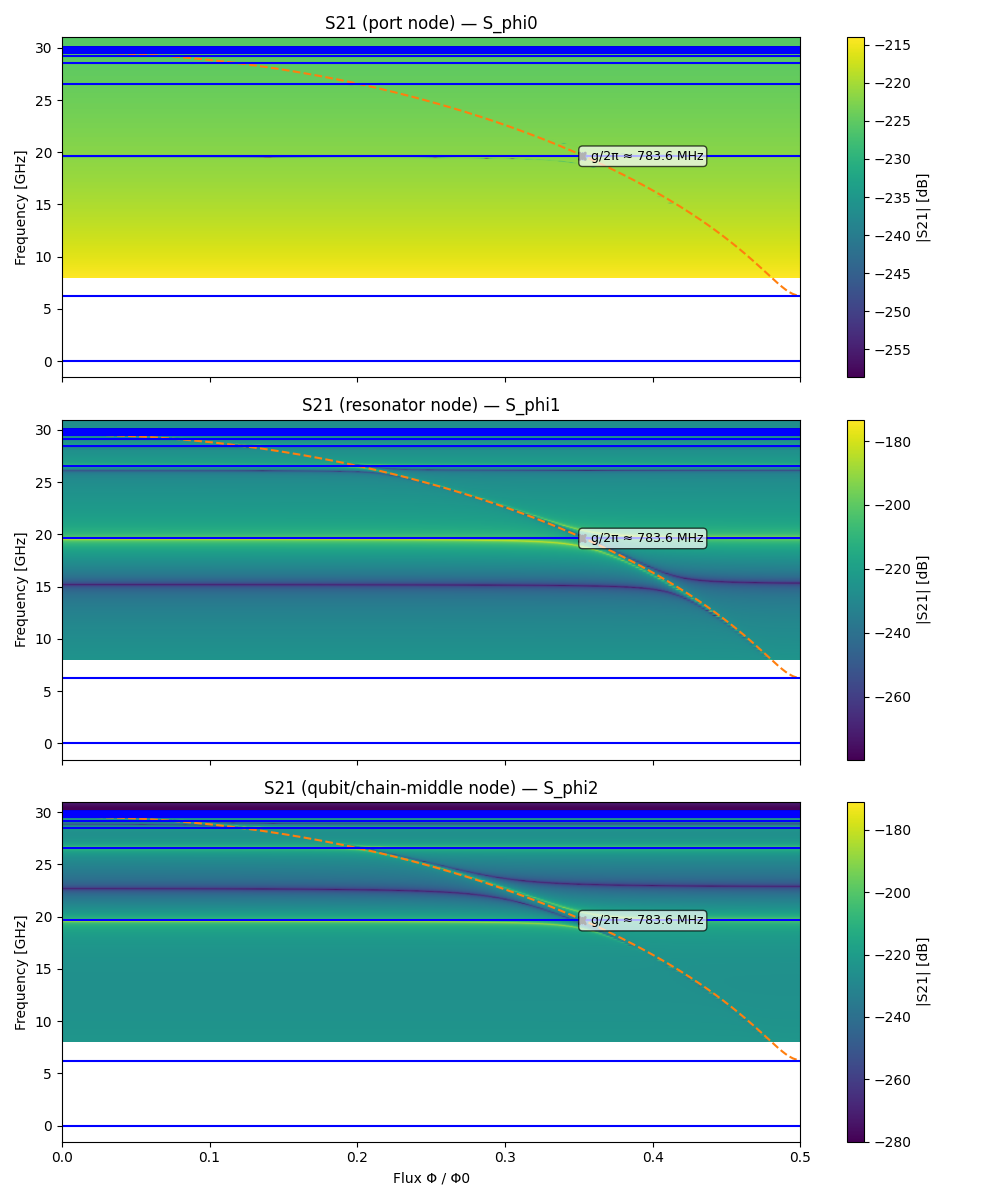

In [240]:
###############################################################################
# 4) Plot S21 colormaps and show g as an arrow (using S21_dB2)
###############################################################################

# Convert S21 to dB
eps = 1e-14  # to avoid log10(0)
S21_dB0 = 20 * np.log10(np.abs(S_phi0) + eps)
S21_dB1 = 20 * np.log10(np.abs(S_phi1) + eps)
S21_dB2 = 20 * np.log10(np.abs(S_phi2) + eps)

extent = [
    Phi_list[0]/Phi0, Phi_list[-1]/Phi0,
    f_span[0]/1e9,    f_span[-1]/1e9
]

# Frequencies in GHz for the arrow
f_minus_GHz = f_minus / 1e9
f_plus_GHz  = f_plus  / 1e9
Phi_cross_x = Phi_cross_over_Phi0

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

titles = [
    "S21 (port node) — S_phi0",
    "S21 (resonator node) — S_phi1",
    "S21 (qubit/chain-middle node) — S_phi2"
]
S_list = [S21_dB0, S21_dB1, S21_dB2]

for ax, SdB, title in zip(axes, S_list, titles):
    im = ax.imshow(
        SdB.T,
        origin='lower',
        aspect='auto',
        extent=extent,
        cmap='viridis'
    )
    ax.set_ylabel("Frequency [GHz]")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="|S21| [dB]")

    # Draw arrow for the splitting in this colormap
    ax.annotate(
        "",
        xy=(Phi_cross_x, f_plus_GHz),
        xytext=(Phi_cross_x, f_minus_GHz),
        arrowprops=dict(arrowstyle="<->", linewidth=2)
    )

    # Mark mid-point and label g
    f_mid_GHz = 0.5 * (f_plus_GHz + f_minus_GHz)
    ax.plot([Phi_cross_x], [f_mid_GHz], marker="o", markersize=5)

    # plt.plot(Phi_list/Phi0, f_q_list*1e-9, label='simple SQUID')
    ax.plot(Phi_list/Phi0, f_q_list_scq*1e-9, linestyle='--', label='scqubits')
    for f in freq_squid:
        ax.axhline(f*1e-9, color='blue', alpha=1)

    ax.text(
        Phi_cross_x,
        f_mid_GHz,
        f"  g/2π ≈ {g_over_2pi_MHz:.1f} MHz",
        va="center",
        ha="left",
        fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
    )

axes[-1].set_xlabel("Flux Φ / Φ0")
plt.tight_layout()
plt.show()
# plt.close()


In [241]:
Cc_array[0]*1e15

TypeError: 'float' object is not subscriptable

In [ ]:
import numpy as np
import datetime

# ----------------------------------------------------------
# Data to save
# ----------------------------------------------------------
# S_phi0, S_phi1, S_phi2  → your S21 arrays
# f_span, flux_span      → frequency & flux axes
# Cc                     → coupling capacitor

# ----------------------------------------------------------
# Generate unique suffix with timestamp + Cc value (fF)
# ----------------------------------------------------------
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
Cc_fF = Cc_array[0] * 1e15        # convert to fF for human-readable naming
suffix = f"_{timestamp}_Cc{Cc_fF:.3f}fF"

# ----------------------------------------------------------
# Save all arrays
# ----------------------------------------------------------
cache_folder = "simulation_cache"

np.save(f"{cache_folder}/S_phi0{suffix}.npy", S_phi0)
np.save(f"{cache_folder}/S_phi1{suffix}.npy", S_phi1)
np.save(f"{cache_folder}/S_phi2{suffix}.npy", S_phi2)

np.save(f"{cache_folder}/f_span{suffix}.npy", f_span)
np.save(f"{cache_folder}/Phi_list{suffix}.npy", Phi_list)
print("Saved with suffix:", suffix)


Saved with suffix: _20260226_180615_Cc0.100fF


In [ ]:
import numpy as np

# ----------------------------------------------------------
# Insert the suffix printed when saving
# Example:
# suffix = "_20251202_193044_Cc1.5fF"
# ----------------------------------------------------------
suffix = "_20260213_161540_Cc0.018fF"  # <-- UPDATE THIS
cache_folder = "simulation_cache"
# ----------------------------------------------------------
# Load all arrays
# ----------------------------------------------------------
S_phi0 = np.load(f"{cache_folder}/S_phi0{suffix}.npy")
S_phi1 = np.load(f"{cache_folder}/S_phi1{suffix}.npy")
S_phi2 = np.load(f"{cache_folder}/S_phi2{suffix}.npy")

f_span = np.load(f"{cache_folder}/f_span{suffix}.npy")
Phi_list = np.load(f"{cache_folder}/Phi_list{suffix}.npy")

print("Loaded datasets for suffix:", suffix)


Loaded datasets for suffix: _20260213_161540_Cc0.018fF


In [ ]:
'''
TODO

DONE - Cg varies 
DONE - check Cc

DONE - Plot eigenvectors to see mode shapes

DONE - How much the plasmon mode is dressed by the capacitances

MOST IMPORTANT: what is my kappa? Shall ideally be 10 MHz -> kappa is the 2nd optimization parameter to counter Purcell

first chain mode 21-23 GHz

qubit - 5-7 GHz -> what is the coupling? g ~ 500 MHz? What is kappa?
maybe increase the qubit freq to 7?

Then add losses:
loss in chain junctions - R parallel to LJ (loss tangent incerted in G matrix)
loss in Cg - tangent in G matrix


mode positioning: consider with respect to the mode math and the 1-phot/ 2 -photon transitions of the qubit -> another optimization parameter

'''

'\nTODO\n\nDONE - Cg varies \nDONE - check Cc\n\nDONE - Plot eigenvectors to see mode shapes\n\nDONE - How much the plasmon mode is dressed by the capacitances\n\nMOST IMPORTANT: what is my kappa? Shall ideally be 10 MHz -> kappa is the 2nd optimization parameter to counter Purcell\n\nfirst chain mode 21-23 GHz\n\nqubit - 5-7 GHz -> what is the coupling? g ~ 500 MHz? What is kappa?\nmaybe increase the qubit freq to 7?\n\nThen add losses:\nloss in chain junctions - R parallel to LJ (loss tangent incerted in G matrix)\nloss in Cg - tangent in G matrix\n\n\nmode positioning: consider with respect to the mode math and the 1-phot/ 2 -photon transitions of the qubit -> another optimization parameter\n\n'

1. microstrip : 50 Ohm at the ~21 GHz (1st resonator freq) (18-25 GHz window), try 40 GHz plasma freq
2. Sample box design 
3. Charge sensitivity at the half-flux Q (calc EJ/EC)
4. What is the hamiltonian? Check that paper

GOALS:
1. Directly probe the dielectric loss - with SQUID, probe T1
2. Compare Q and kappa against the non-linear bow-tie resonators (lumped Cc vs distributed Cc) - no SQUID
3. Check if impedance mismatch indeed protects the mode - with SQUID, probe T1

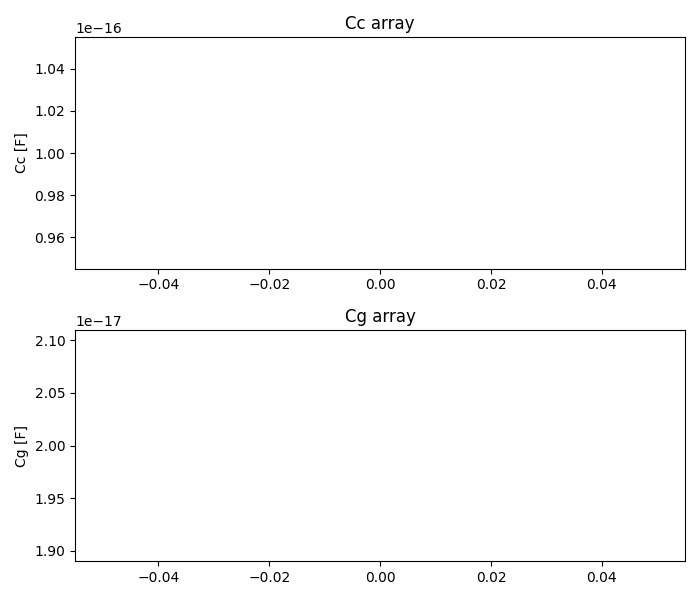

In [ ]:
plt.figure(figsize=(7,6))
plt.subplot(2,1,1)
plt.plot(np.arange(len(Cc_array)), Cc_array)
plt.title("Cc array")
plt.ylabel("Cc [F]")
plt.subplot(2,1,2)
plt.plot(np.arange(len(Cg_array)), Cg_array)
plt.title("Cg array")
plt.ylabel("Cg [F]")
plt.tight_layout()
plt.show()